# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import itertools
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

## Wczytanie i analiza danych

In [ ]:
df = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")
display(df.head())
display(df.describe())
display(df.info())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

None

In [ ]:
print("Unikalne wartości w danych kolumnach obiektowych")
print(40*"=")
print(f"FAVC: {df['FAVC'].unique()}")
print(f"CAEC: {df['CAEC'].unique()}")
print(f"SMOKE: {df['SMOKE'].unique()}")
print(f"SCC: {df['SCC'].unique()}")
print(f"CALC: {df['CALC'].unique()}")
print(f"MTRANS: {df['MTRANS'].unique()}")
print(f"NObeyesdad: {df['NObeyesdad'].unique()}")

Unikalne wartości w danych kolumnach obiektowych
FAVC: ['no' 'yes']
CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE: ['no' 'yes']
SCC: ['no' 'yes']
CALC: ['no' 'Sometimes' 'Frequently' 'Always']
MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
NObeyesdad: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


|Cecha|Typ|Opis|Dane|
|---|---|---|---|
|Gender|`object`|Płeć|Male - mężczyzna, Female - kobieta|
|Age|`float64`|Wiek|zakres wieku badanych: 14-61|
|Height|`float64`|Wzrost w metrach|Zakres: 1.45-1.98|
|Weight|`float64`|Waga w kg|Zakres: 39-173|
|family_history_with_overweight|`object`|Czy członek rodziny chorował lub choruje na otyłość|*yes* / *no*|
|FAVC|`object`|Czy często jesz wysokokaloryczne jedzenie?|*yes* / *no*|
|FCVC|`float64`|Czy zazwyczaj spożywasz warzywa?|Skala 1-3|
|NCP|`float64`|Jak dużo większych posiłków spożywasz w ciągu dnia?|Zakres 1-4|
|CAEC|`object`|Czy jest cokolwiek między posiłkami?|Cztery warianty: nie, czasami, często, zawsze|
|SMOKE|`object`|Czy palisz?|*yes* / *no*|
|CH2O|`float64`|Jak dużo wody pijesz w ciągu dnia w litrach?|Zakres: 1-3|
|SCC|`object`|Czy monitorujesz ilość spożytych kalorii w ciągu dnia?|*yes* / *no*|
|FAF|`float64`|Jak często utrzymujesz aktywność fizyczną?|Zakres 0-3|
|TUE|`flooat64`|Ile czasu spędzasz przed urządzeniami?|Zakres 0-2|
|CALC|`object`|Jak często spożywasz alkohol?|4 warianty: nie, czasami, często, zawsze|
|MTRANS|`object`|W jaki sposób najczęściej się poruszasz?|5 możliwych środków: pieszo, samochodem, rowerem, motorem, transportem publicznym|
|NObeyesdad|`object`|Poziom otyłości|7 różnych możliwości|

Zamieniamy kolumny ze stałymi wartościami tekstowymi na:
- 1-0 w przypadku tak-nie
- 0-3 w przypadku częstotliwości nie(0)-zawsze(3)
- 0-4 w przypadku rodzaju transportu: 0-pieszo, 1-trans_publicz, 2-samochód, 3-motor, 4-rower

In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'yes': 1, 'no': 0})
df['FAVC'] = df['FAVC'].map({'yes': 1, 'no': 0})
df['SMOKE'] = df['SMOKE'].map({'yes': 1, 'no': 0})
df['SCC'] = df['SCC'].map({'yes': 1, 'no': 0})

df['CAEC'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df['CALC'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

df['MTRANS'] = df['MTRANS'].map({'Walking': 0, 'Public_Transportation': 1, 'Automobile': 2, 'Motorbike': 3, 'Bike': 4})
df['Passive_Transport'] = df['MTRANS'].map({0: 0, 4: 0, 1: 1, 2: 1, 3: 1})
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,Passive_Transport
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,1,Normal_Weight,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,1,Normal_Weight,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,1,Normal_Weight,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,0,Overweight_Level_I,0
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,1,Overweight_Level_II,1


In [ ]:
target_map = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}

df['NObeyesdad'] = df['NObeyesdad'].map(target_map)

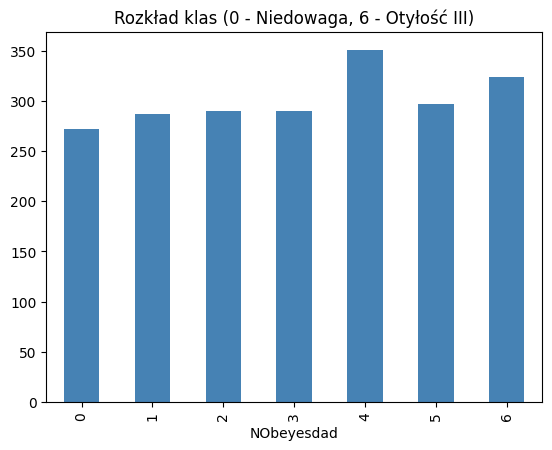

In [ ]:
df['NObeyesdad'].value_counts().sort_index().plot(kind='bar', color='steelblue')

plt.title('Rozkład klas (0 - Niedowaga, 6 - Otyłość III)')
plt.show()

Rozkład klas jest w miarę równomierny, więc nie musimy się obawiać, że model mógłby zostać zdominowany przez konkretne wyniki.

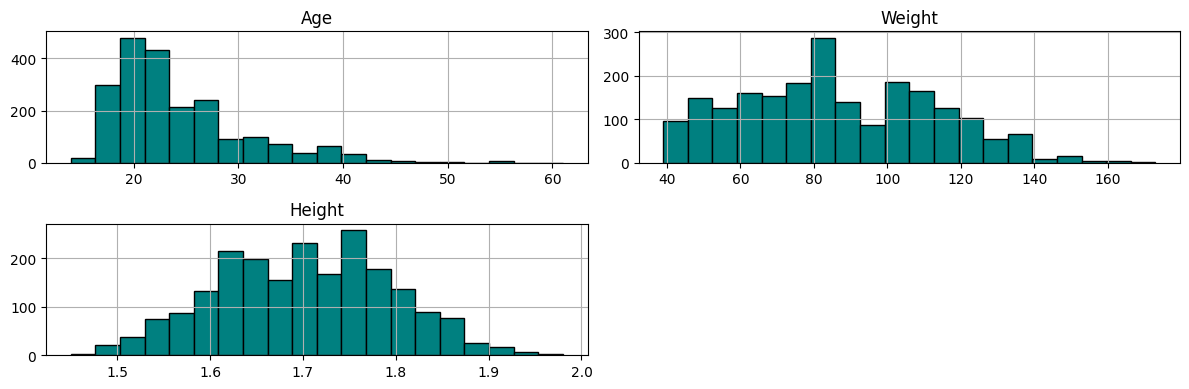

In [ ]:
df[['Age', 'Weight', 'Height']].hist(bins=20, figsize=(12, 4), color='teal', edgecolor='black')
plt.tight_layout()
plt.show()

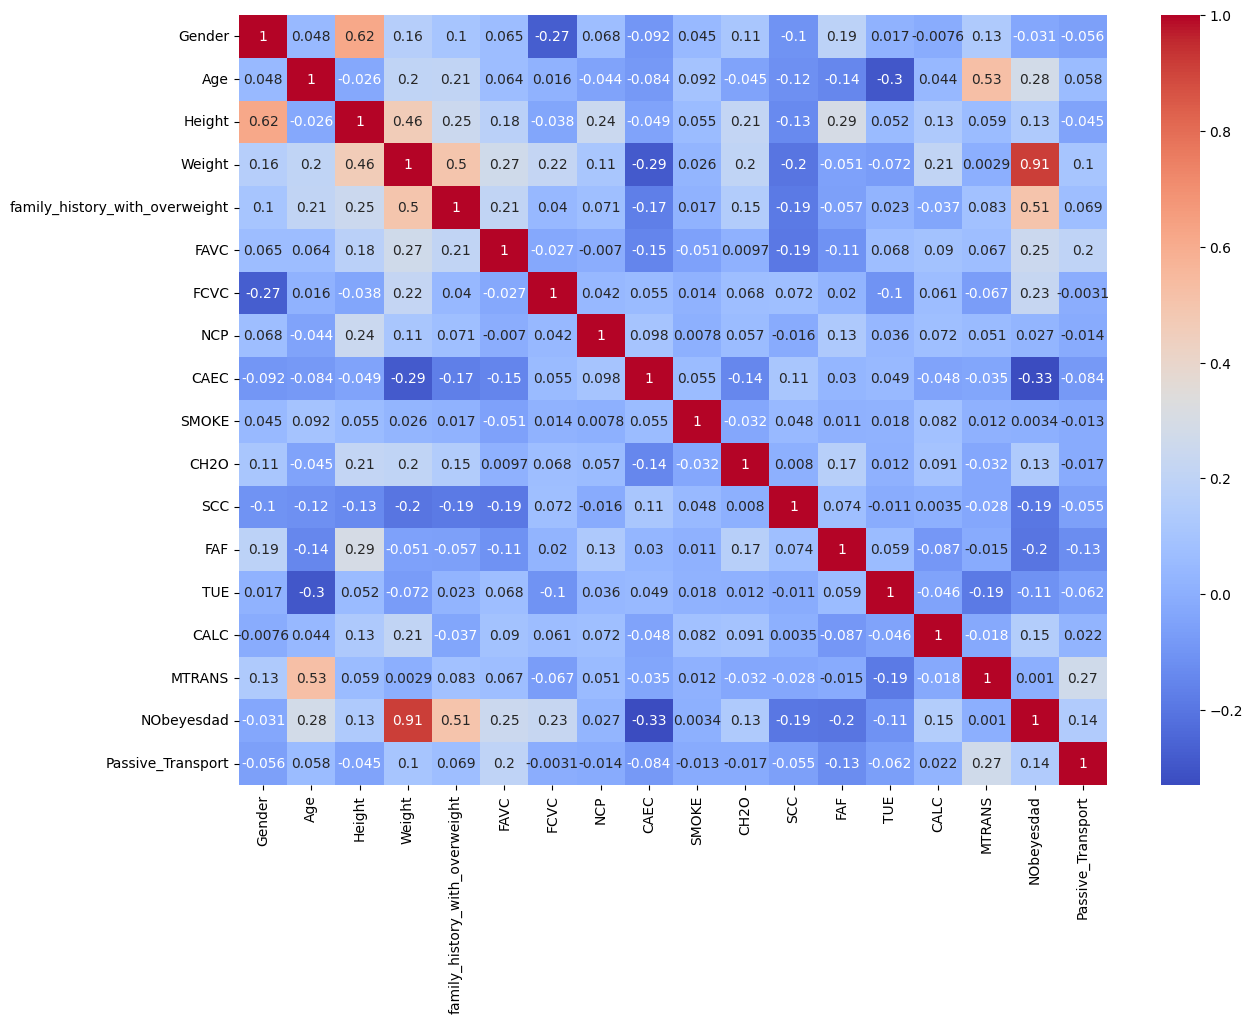

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

### Wnioski z macierzy korelacji:
- największą korelację z wynikiem otyłości ma waga, co nie jest zaskoczeniem. Jednak nie ma sensu wdrażać modelu AI do ministerstwa jeśli skupi się on przede wszytskim na tym, co można zauważyć i wyliczyć ręcznie. Zatem trzeba usunąć wagę i wzrost
- środek transportu nie ma wysokiej korelacji z stanem otyłości, ale cecha mówiąca o tym czy dana osoba porusza się aktywnie czy biernie już bardziej. Zatem cechę `MTRANS` też można usunąć
- korelacja palenia i otyłości również jest bardzo mała, zatem cechę `SMOKE` też można usunąć.

In [ ]:
df.drop(columns=['Weight', 'Height', 'MTRANS', 'SMOKE'], inplace=True)
df.head()

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,Passive_Transport
0,0,21.0,1,0,2.0,3.0,1,2.0,0,0.0,1.0,0,1,1
1,0,21.0,1,0,3.0,3.0,1,3.0,1,3.0,0.0,1,1,1
2,1,23.0,1,0,2.0,3.0,1,2.0,0,2.0,1.0,2,1,1
3,1,27.0,0,0,3.0,3.0,1,2.0,0,2.0,0.0,2,2,0
4,1,22.0,0,0,2.0,1.0,1,2.0,0,0.0,0.0,1,3,1


## Podział danych na zbiory

In [ ]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}")

Rozmiar zbioru treningowego: 1688
Rozmiar zbioru testowego: 423


## 2.1 Pojedyncze drzewo decyzyjne

In [ ]:

tree = DecisionTreeClassifier(random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(tree, X_train, y_train, cv=cv_strategy, scoring="f1_macro")

print("=== Wyniki walidacji krzyżowej ===")
print(f"Średnia dokładność: {cv_scores.mean():.4f}")
print(f"Odchylenie standardowe: {cv_scores.std():.4f}")

=== Wyniki walidacji krzyżowej ===
Średnia dokładność: 0.7508
Odchylenie standardowe: 0.0238


In [ ]:
tree.fit(X_train, y_train)
start_time = time.perf_counter()
y_pred = tree.predict(X_test)
inference_time = time.perf_counter() - start_time

print(f"Czas predykcji: {inference_time:.4f}s")
target_names = [
    'Niedowaga (0)', 'Waga normalna (1)', 'Nadwaga I (2)',
    'Nadwaga II (3)', 'Otyłość I (4)', 'Otyłość II (5)', 'Otyłość III (6)'
]
print(classification_report(y_test, y_pred, target_names=target_names))

Czas predykcji: 0.0047s
                   precision    recall  f1-score   support

    Niedowaga (0)       0.80      0.83      0.82        54
Waga normalna (1)       0.49      0.48      0.49        58
    Nadwaga I (2)       0.62      0.69      0.65        58
   Nadwaga II (3)       0.72      0.66      0.68        58
    Otyłość I (4)       0.78      0.74      0.76        70
   Otyłość II (5)       0.90      0.92      0.91        60
  Otyłość III (6)       0.98      0.97      0.98        65

         accuracy                           0.76       423
        macro avg       0.76      0.76      0.76       423
     weighted avg       0.76      0.76      0.76       423



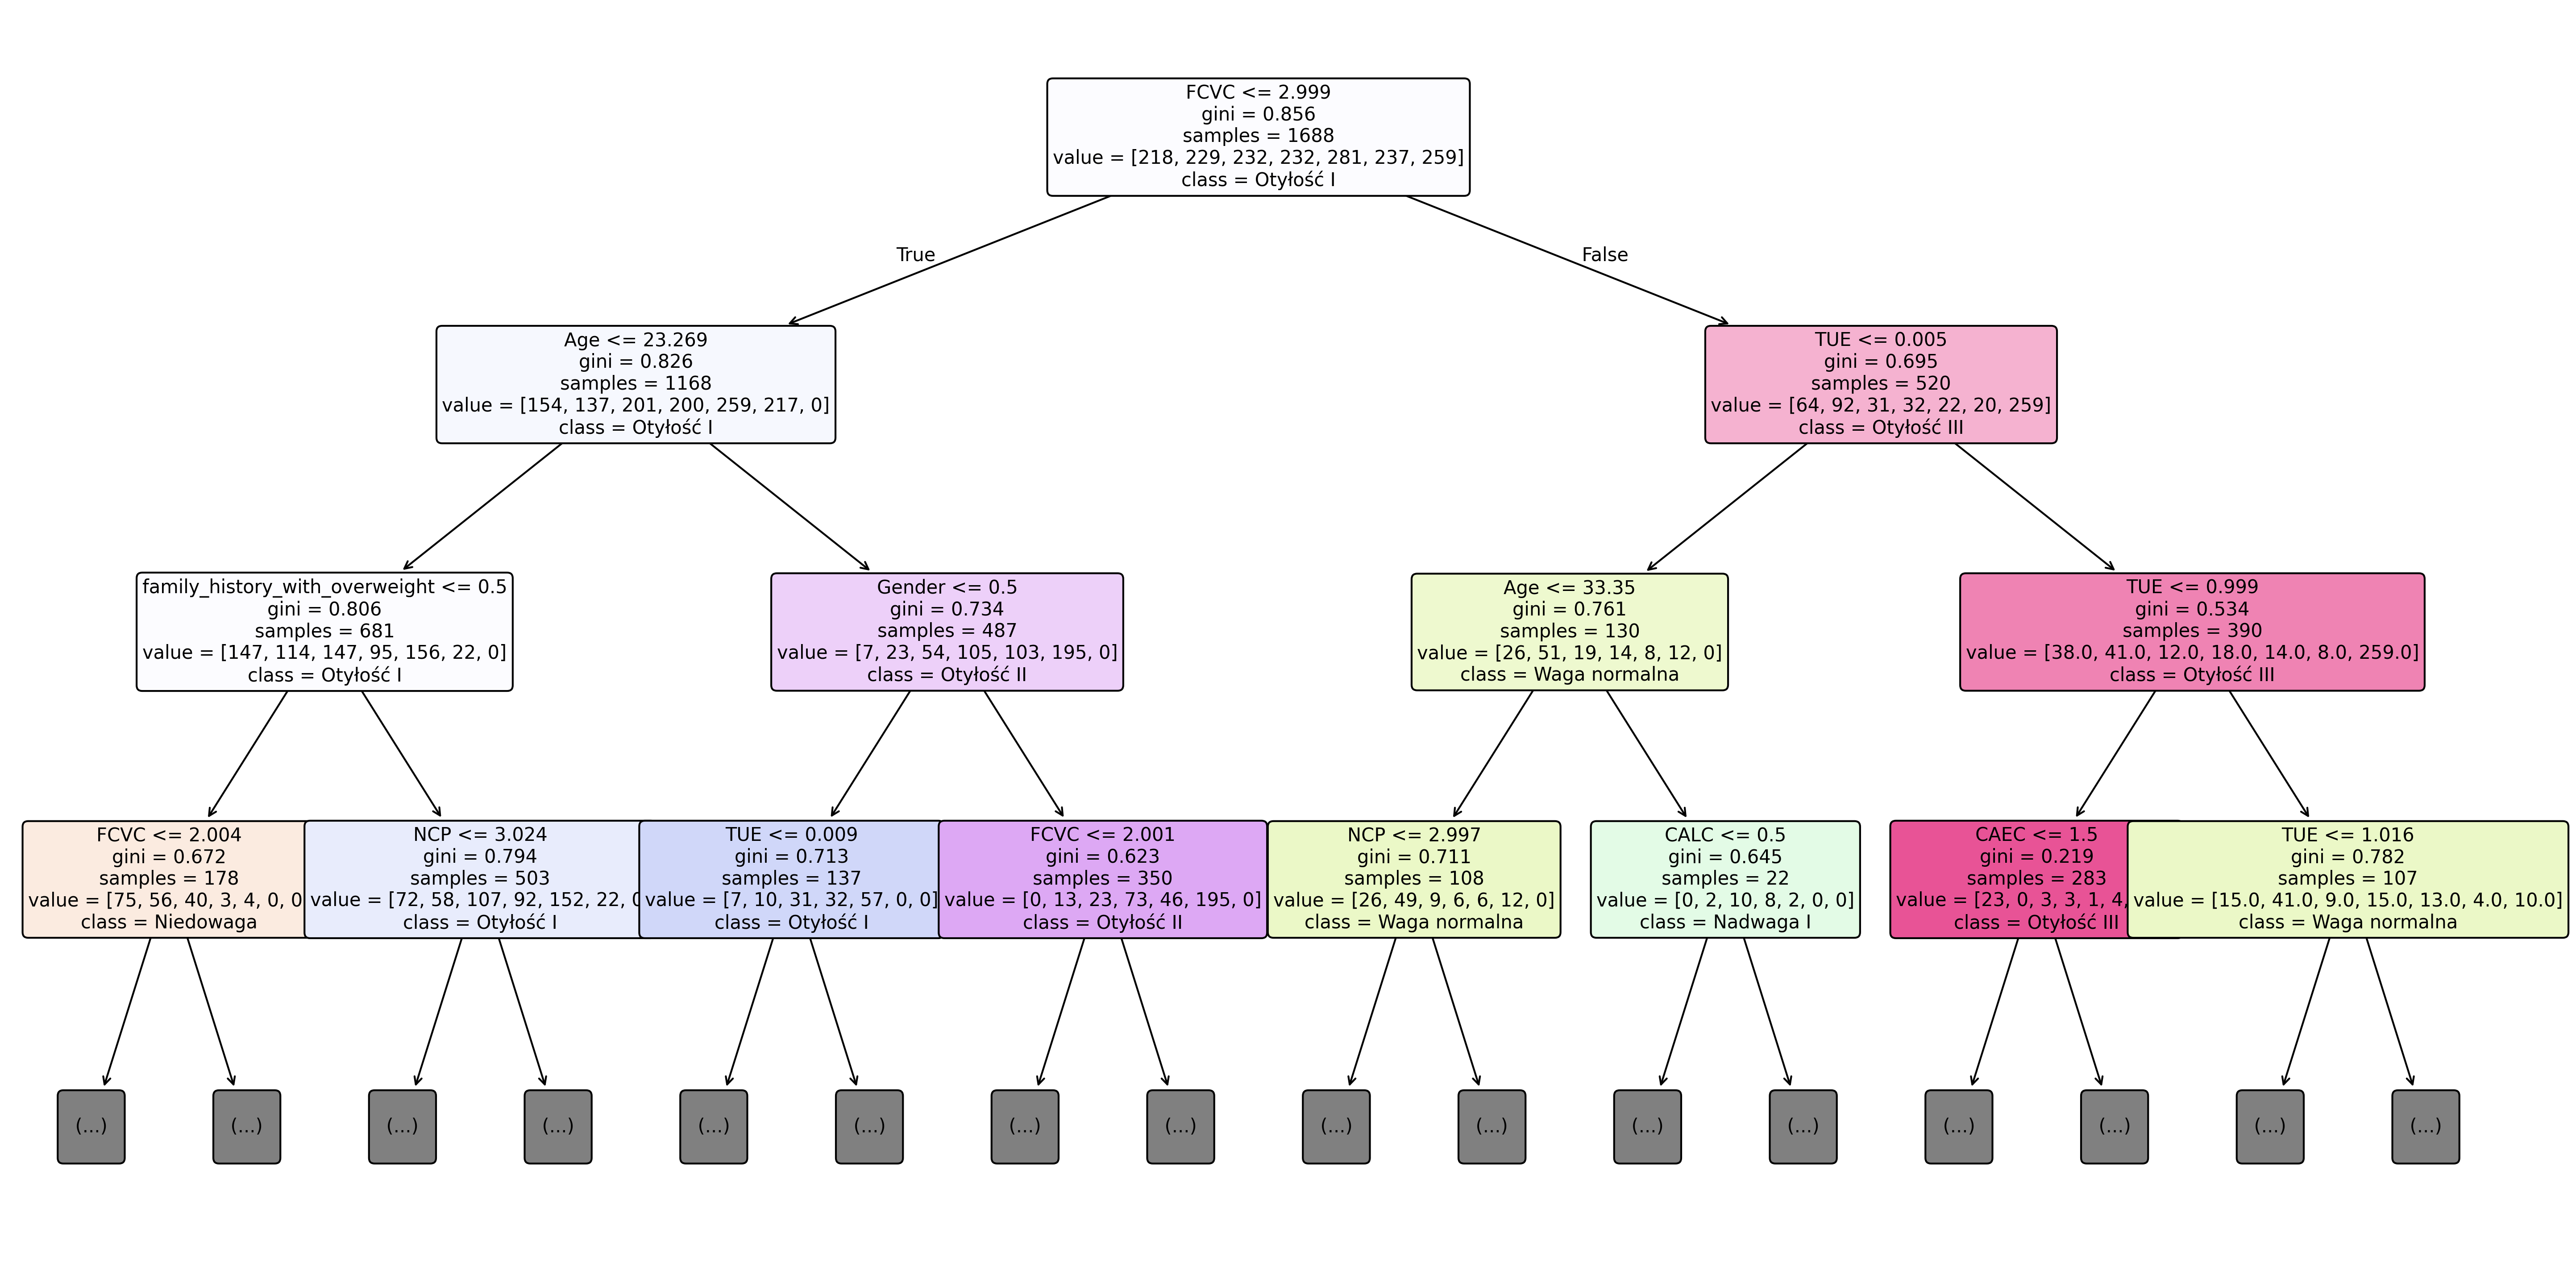

In [ ]:
class_names = [
    'Niedowaga', 'Waga normalna', 'Nadwaga I',
    'Nadwaga II', 'Otyłość I', 'Otyłość II', 'Otyłość III'
]
plt.figure(figsize=(24, 12), dpi=300)
plot_tree(tree, max_depth=3, filled=True, feature_names=X.columns, class_names=class_names, rounded=True, fontsize=10)
plt.show()

Text(0.5, 1.0, 'Macierz błędów - pojedyncze drzewo')

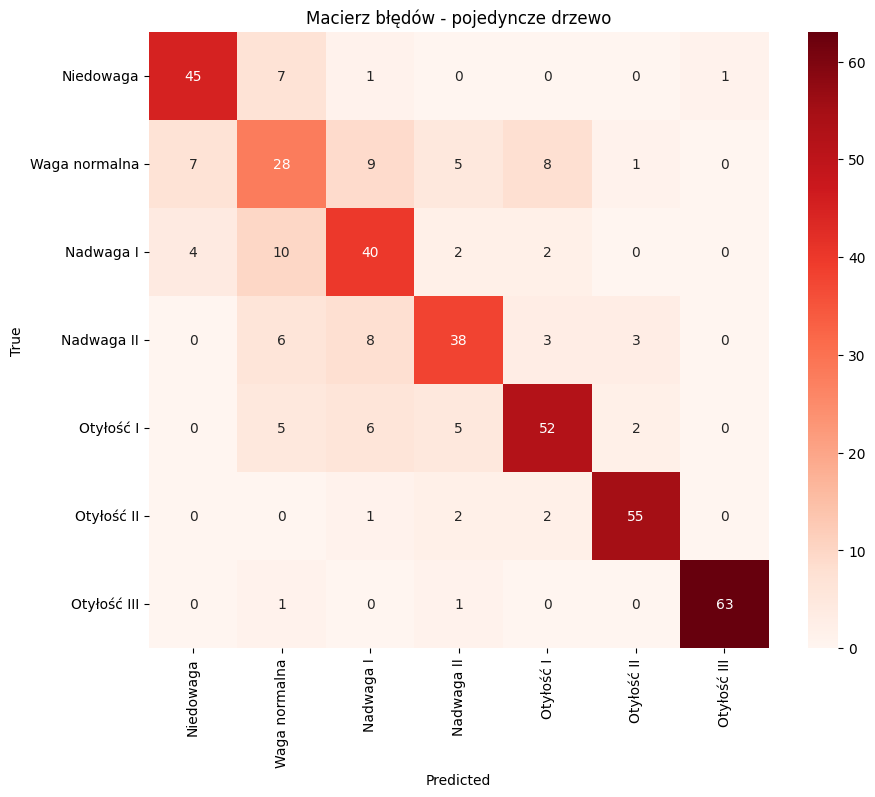

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz błędów - pojedyncze drzewo')

In [ ]:
# próba pruningu nie przyniosła polepszenia wyników
param_grid = {
    'max_depth': [3, 5, 7, 10, 12, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'min_samples_split': [2, 10, 20, 50]
}

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(f"Najlepsze parametry: {best_params}")

best_tree = grid_search.best_estimator_
y_pred_pruned = best_tree.predict(X_test)

print("\n=== RAPORT KLASYFIKACJI (PRZYCIĘTE DRZEWO) ===")
target_names = [
    'Niedowaga (0)', 'Waga normalna (1)', 'Nadwaga I (2)',
    'Nadwaga II (3)', 'Otyłość I (4)', 'Otyłość II (5)', 'Otyłość III (6)'
]
print(classification_report(y_test, y_pred_pruned, target_names=target_names))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Najlepsze parametry: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

=== RAPORT KLASYFIKACJI (PRZYCIĘTE DRZEWO) ===
                   precision    recall  f1-score   support

    Niedowaga (0)       0.80      0.83      0.82        54
Waga normalna (1)       0.49      0.48      0.49        58
    Nadwaga I (2)       0.62      0.69      0.65        58
   Nadwaga II (3)       0.72      0.66      0.68        58
    Otyłość I (4)       0.78      0.74      0.76        70
   Otyłość II (5)       0.90      0.92      0.91        60
  Otyłość III (6)       0.98      0.97      0.98        65

         accuracy                           0.76       423
        macro avg       0.76      0.76      0.76       423
     weighted avg       0.76      0.76      0.76       423



## 2.2 Regresja Logistyczna

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
cv_scores_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=cv_strategy, scoring="f1_macro")

print("=== Wyniki walidacji krzyżowej ===")
print(f"Średnia dokładność: {cv_scores_lr.mean():.4f}")
print(f"Odchylenie standardowe: {cv_scores_lr.std():.4f}")

=== Wyniki walidacji krzyżowej ===
Średnia dokładność: 0.5465
Odchylenie standardowe: 0.0194


In [ ]:
lr_pipeline.fit(X_train, y_train)
start_time = time.perf_counter()
y_pred_lr = lr_pipeline.predict(X_test)
inference_time = time.perf_counter() - start_time

print(f"Czas predykcji: {inference_time:.4f}s")
print("Raport klasyfikacji dla regresji logistycznej:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

Czas predykcji: 0.0078s
Raport klasyfikacji dla regresji logistycznej:
                   precision    recall  f1-score   support

    Niedowaga (0)       0.56      0.56      0.56        54
Waga normalna (1)       0.50      0.41      0.45        58
    Nadwaga I (2)       0.52      0.41      0.46        58
   Nadwaga II (3)       0.44      0.21      0.28        58
    Otyłość I (4)       0.44      0.53      0.48        70
   Otyłość II (5)       0.52      0.82      0.63        60
  Otyłość III (6)       0.93      0.97      0.95        65

         accuracy                           0.57       423
        macro avg       0.56      0.56      0.54       423
     weighted avg       0.56      0.57      0.55       423



Text(0.5, 1.0, 'Macierz błędów')

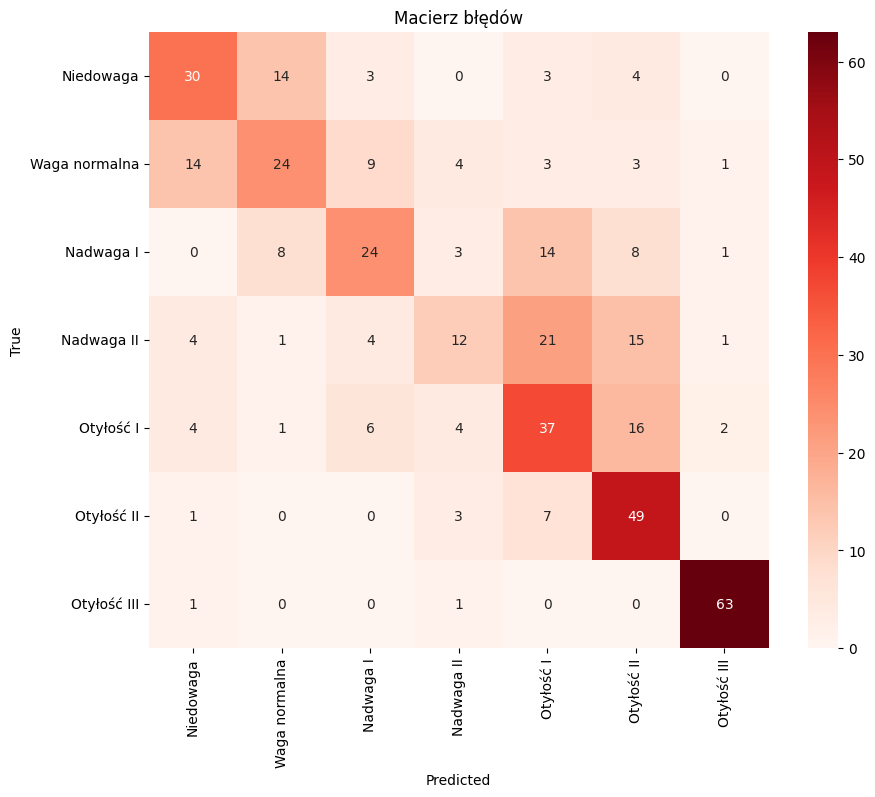

In [ ]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz błędów')

In [ ]:
param_grid = [
    {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs']
    },
    {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear']
    }
]
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print(f"Najlepsze parametry dla regresji logistycznej: {best_params_lr}")
best_lr = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

print("\n=== RAPORT KLASYFIKACJI (PRZYCIĘTA REGRESJA LOGISTYCZNA) ===")
print(classification_report(y_test, y_pred_lr_tuned, target_names=target_names))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Najlepsze parametry dla regresji logistycznej: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

=== RAPORT KLASYFIKACJI (PRZYCIĘTA REGRESJA LOGISTYCZNA) ===
                   precision    recall  f1-score   support

    Niedowaga (0)       0.56      0.56      0.56        54
Waga normalna (1)       0.51      0.41      0.46        58
    Nadwaga I (2)       0.52      0.43      0.47        58
   Nadwaga II (3)       0.45      0.22      0.30        58
    Otyłość I (4)       0.45      0.54      0.49        70
   Otyłość II (5)       0.52      0.82      0.63        60
  Otyłość III (6)       0.95      0.97      0.96        65

         accuracy                           0.57       423
        macro avg       0.57      0.56      0.55       423
     weighted avg       0.57      0.57      0.56       423



## 2.3 Bagging

In [ ]:
base_models = {
    "Płytkie Drzewo": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Głębokie Drzewo": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Regresja Logistyczna": lr_pipeline
}

experiments = [
    ("Płytkie Drzewo", {"n_estimators": 10, "bootstrap": True, "bootstrap_features": False}),
    ("Płytkie Drzewo", {"n_estimators": 100, "bootstrap": True, "bootstrap_features": False}),

    ("Głębokie Drzewo", {"n_estimators": 10, "bootstrap": True, "bootstrap_features": False}),
    ("Głębokie Drzewo", {"n_estimators": 10, "bootstrap": False, "bootstrap_features": False}),
    ("Głębokie Drzewo", {"n_estimators": 10, "bootstrap": True, "bootstrap_features": True}),

    ("Regresja Logistyczna", {"n_estimators": 10, "bootstrap": True, "bootstrap_features": False})
]

print("=== PORÓWNANIE MODELI I PARAMETRÓW - BAGGING ===")
print(f"{'Model Bazowy':<22} | {'n_est':<5} | {'boot':<5} | {'feat':<5} || {'Acc':<6} | {'Recall':<6} | {'F1-Mac':<6} | {'Conf':<6} | {'Czas [s]':<6}")
print("-" * 90)

for base_name, params in experiments:

    model = BaggingClassifier(
        estimator=base_models[base_name],
        n_estimators=params["n_estimators"],
        bootstrap=params["bootstrap"],
        bootstrap_features=params["bootstrap_features"],
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    inference_time = time.perf_counter() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    probabilities = model.predict_proba(X_test)
    confidence = np.mean(np.max(probabilities, axis=1))

    print(f"{base_name:<22} | {params['n_estimators']:<5} | {str(params['bootstrap']):<5} | {str(params['bootstrap_features']):<5} || "
          f"{accuracy*100:>5.1f}% | {recall*100:>5.1f}% | {f1*100:>5.1f}% | {confidence*100:>5.1f}% | {inference_time:.4f}")

=== PORÓWNANIE MODELI I PARAMETRÓW - BAGGING ===
Model Bazowy           | n_est | boot  | feat  || Acc    | Recall | F1-Mac | Conf   | Czas [s]
------------------------------------------------------------------------------------------
Płytkie Drzewo         | 10    | True  | False ||  52.7% |  51.1% |  45.3% |  46.4% | 0.0260
Płytkie Drzewo         | 100   | True  | False ||  53.9% |  52.3% |  46.2% |  45.1% | 0.1082
Głębokie Drzewo        | 10    | True  | False ||  78.7% |  78.5% |  78.3% |  78.6% | 0.0262
Głębokie Drzewo        | 10    | False | False ||  76.4% |  76.2% |  76.2% |  92.5% | 0.0130
Głębokie Drzewo        | 10    | True  | True  ||  77.5% |  77.4% |  77.4% |  66.5% | 0.0234
Regresja Logistyczna   | 10    | True  | False ||  57.7% |  57.1% |  56.0% |  55.5% | 0.0237


## 2.4 AdaBoost i GradientBoosting

In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_estimators_list = [20, 100, 300]
learning_rates = [0.5, 0.1, 0.01]

print(f"{'Model / Algorytm':<28} | {'n_est':<5} | {'LR':<5} || {'Acc':<6} | {'Recall':<6} | {'F1-Mac':<6} | {'Conf':<6} | {'Czas [s]':<6}")
print("-" * 92)

ada_experiments = [
    ("AdaBoost (Płytkie Drzewo)", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=50, random_state=42), X_train, X_test),
    ("AdaBoost (Regresja Log)", AdaBoostClassifier(estimator=LogisticRegression(random_state=42, max_iter=1000), n_estimators=50, random_state=42), X_train_scaled, X_test_scaled)
]

for name, model, xtr, xte in ada_experiments:
    model.fit(xtr, y_train)
    start_time = time.perf_counter()
    y_pred = model.predict(xte)
    inf_time = time.perf_counter() - start_time

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    conf = np.mean(np.max(model.predict_proba(xte), axis=1))

    print(f"{name:<28} | {'50':<5} | {'1.0':<5} || {acc*100:>5.1f}% | {rec*100:>5.1f}% | {f1*100:>5.1f}% | {conf*100:>5.1f}% | {inf_time:.4f}")

print("-" * 92)

for n_est in n_estimators_list:
    for lr in learning_rates:
        model = GradientBoostingClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=3,
            random_state=42
        )

        model.fit(X_train, y_train)

        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        inf_time = time.perf_counter() - start_time

        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        conf = np.mean(np.max(model.predict_proba(X_test), axis=1))

        print(f"{'Gradient Boosting':<28} | {n_est:<5} | {lr:<5} || {acc*100:>5.1f}% | {rec*100:>5.1f}% | {f1*100:>5.1f}% | {conf*100:>5.1f}% | {inf_time:.4f}")

Model / Algorytm             | n_est | LR    || Acc    | Recall | F1-Mac | Conf   | Czas [s]
--------------------------------------------------------------------------------------------
AdaBoost (Płytkie Drzewo)    | 50    | 1.0   ||  47.0% |  46.3% |  44.9% |  14.5% | 0.0126
AdaBoost (Regresja Log)      | 50    | 1.0   ||  48.0% |  47.4% |  47.6% |  14.7% | 0.0160
--------------------------------------------------------------------------------------------
Gradient Boosting            | 20    | 0.5   ||  77.3% |  77.0% |  76.9% |  78.4% | 0.0042
Gradient Boosting            | 20    | 0.1   ||  75.9% |  75.7% |  75.3% |  55.7% | 0.0038
Gradient Boosting            | 20    | 0.01  ||  61.0% |  59.6% |  57.7% |  22.3% | 0.0037
Gradient Boosting            | 100   | 0.5   ||  80.9% |  80.6% |  80.7% |  89.1% | 0.0083
Gradient Boosting            | 100   | 0.1   ||  79.7% |  79.6% |  79.5% |  75.8% | 0.0120
Gradient Boosting            | 100   | 0.01  ||  67.8% |  67.1% |  66.5% |  41.5% | 

## 2.5 Stack & Voting

In [ ]:
sub_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sub_bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
                            n_estimators=10, bootstrap=True, bootstrap_features=True, n_jobs=-1, random_state=42)
sub_lr = lr_pipeline

estimators_list = [
    ('gb', sub_gb),
    ('bag', sub_bag),
    ('lr', sub_lr)
]

final_committees = [
    ("Voting Classifier (Soft)", VotingClassifier(
        estimators=estimators_list,
        voting='soft',
        n_jobs=-1
    )),
    ("Stacking Classifier", StackingClassifier(
        estimators=estimators_list,
        final_estimator=LogisticRegression(random_state=42, max_iter=1000),
        n_jobs=-1,
        passthrough=False
    ))
]

print(f"{'Komitet Autorski':<28} || {'Acc':<6} | {'Recall':<6} | {'F1-Mac':<6} | {'Conf':<6} | {'Czas [s]':<6}")
print("-" * 75)

for name, model in final_committees:
    model.fit(X_train, y_train)

    start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    inference_time = time.perf_counter() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    probabilities = model.predict_proba(X_test)
    confidence = np.mean(np.max(probabilities, axis=1))

    print(f"{name:<28} || {accuracy*100:>5.1f}% | {recall*100:>5.1f}% | {f1*100:>5.1f}% | {confidence*100:>5.1f}% | {inference_time:.4f}")

Komitet Autorski             || Acc    | Recall | F1-Mac | Conf   | Czas [s]
---------------------------------------------------------------------------
Voting Classifier (Soft)     ||  80.9% |  80.8% |  80.8% |  62.6% | 0.0268
Stacking Classifier          ||  82.5% |  82.5% |  82.5% |  81.3% | 0.0984


## Podsumowanie

#### Macierze pomyłek dla modeli Ensemble

Text(0.5, 1.0, 'Macierz błędów - Bagging')

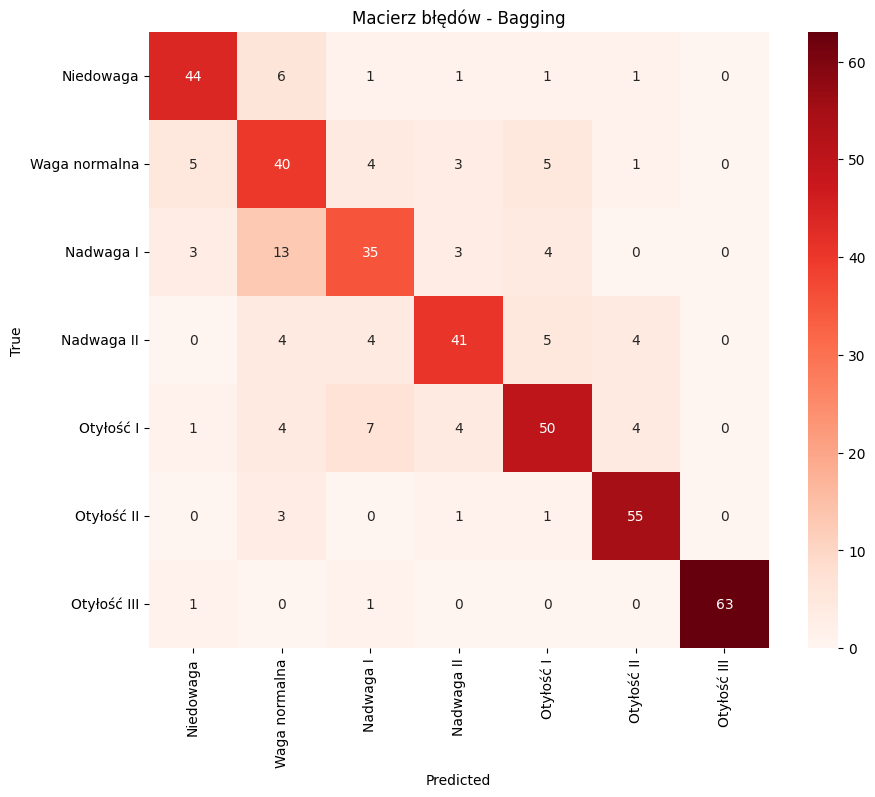

In [ ]:
#bagging
best_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),n_estimators=10, bootstrap=True, bootstrap_features=True, n_jobs=-1, random_state=42)
best_bagging_model.fit(X_train, y_train)
y_pred_bagging = best_bagging_model.predict(X_test)
conf_matrix_bagging = confusion_matrix(y_test, y_pred_bagging)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_bagging, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz błędów - Bagging')

Text(0.5, 1.0, 'Macierz błędów - GradientBoosting')

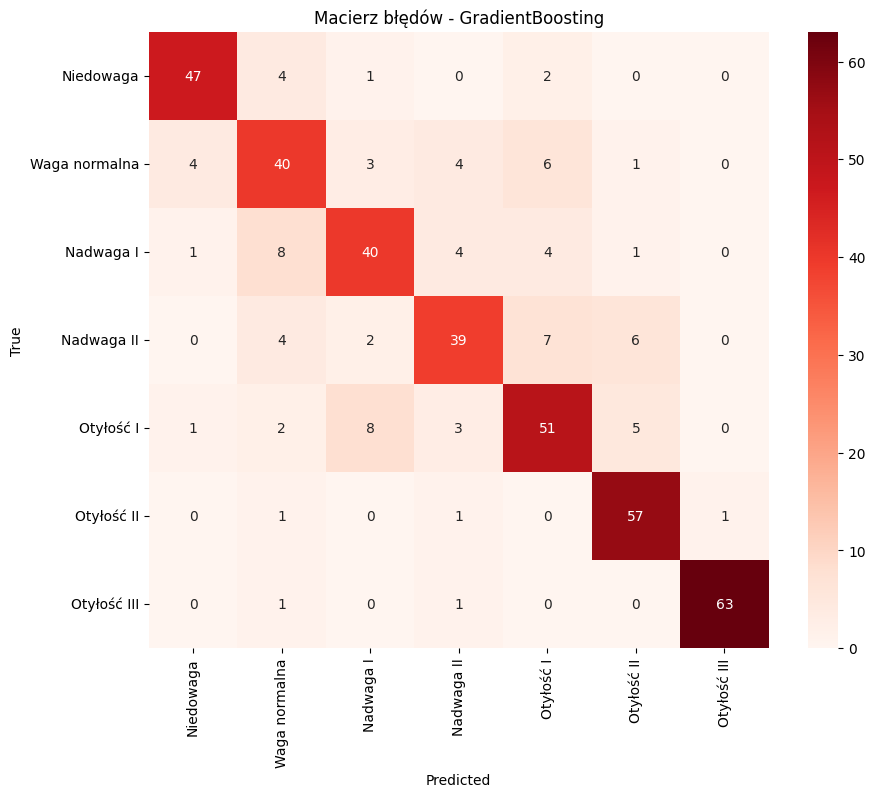

In [ ]:
#boosting
best_boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
best_boosting_model.fit(X_train, y_train)
y_pred_boosting = best_boosting_model.predict(X_test)
conf_matrix_boosting = confusion_matrix(y_test, y_pred_boosting)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_boosting, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz błędów - GradientBoosting')

Text(0.5, 1.0, 'Macierz błędów - Voting')

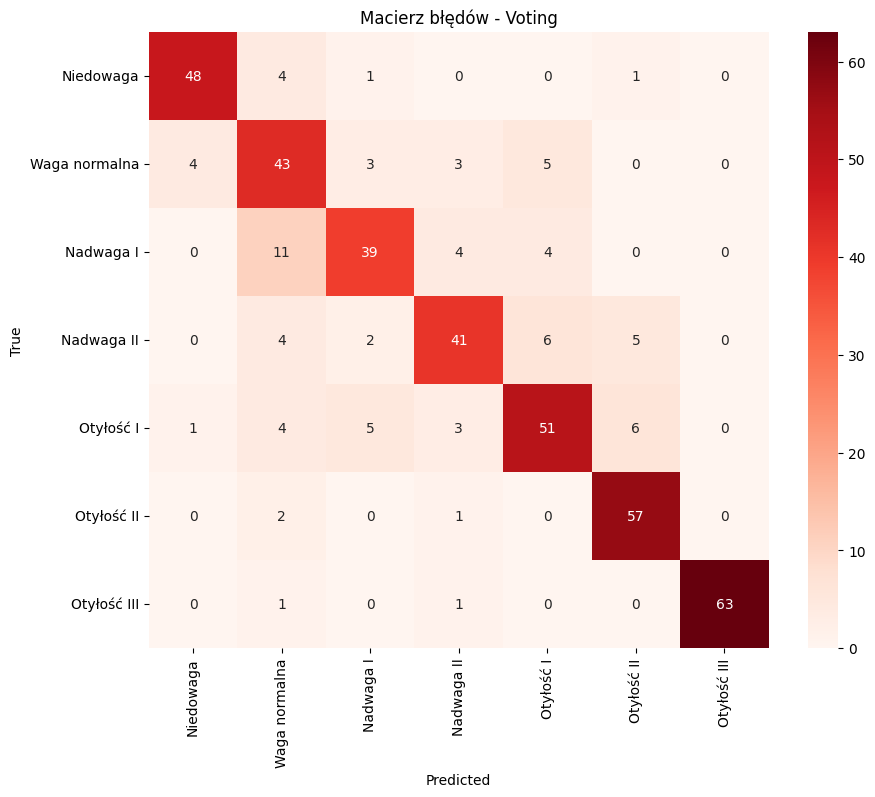

In [ ]:
#Voting
best_voting_model = VotingClassifier(estimators=[('gb', sub_gb), ('bag', sub_bag), ('lr', sub_lr)], voting='soft', n_jobs=-1)
best_voting_model.fit(X_train, y_train)
y_pred_voting = best_voting_model.predict(X_test)
conf_matrix_voting = confusion_matrix(y_test, y_pred_voting)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_voting, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz błędów - Voting')

Text(0.5, 1.0, 'Macierz błędów - Stacking')

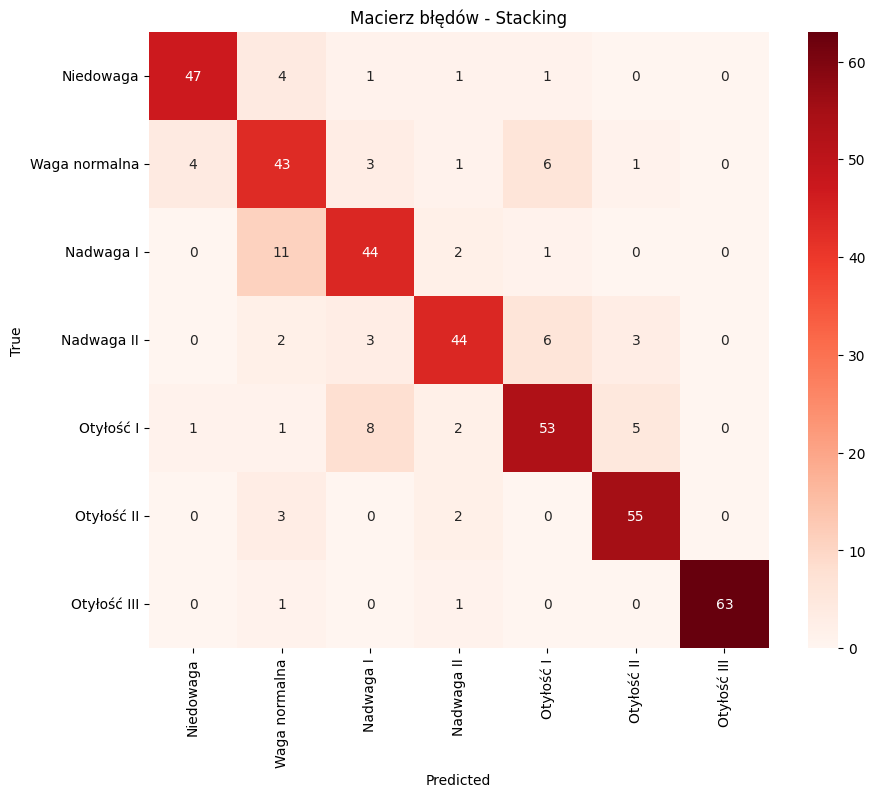

In [ ]:
#stacking
best_stacking_model = StackingClassifier(estimators=[('gb', sub_gb), ('bag', sub_bag), ('lr', sub_lr)], final_estimator=LogisticRegression(random_state=42, max_iter=1000), n_jobs=-1, passthrough=False)
best_stacking_model.fit(X_train, y_train)
y_pred_stacking = best_stacking_model.predict(X_test)
conf_matrix_stacking = confusion_matrix(y_test, y_pred_stacking)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_stacking, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz błędów - Stacking')

#### Raport dla Ministerstwa

1. Cel działania

Celem projektu było stworzenie modelu, który musi połączyć precyzyjne działanie z prostotą obliczeniową, aby mógł zostać wdrożony nawet w wiejskich przychodniach o ograniczonych zasobach. Model ma za zadanie pomóc w identyfikacji osób, które wymagają lub mogą wymagać interwencji profilaktycznej. Głównym celem jest ograniczenie do 2030 o co najmniej 1/3 przedwczesnej umieralności z powodu chorób wynikających z otyłości. Z tej racji model musi analizować obecne zachowania i nawyki żywieniowe, które mogą mieć wpływ na przyszłą możliowść otyłości wśród badanych osób.

2. Kryteria doboru miar

Opieranie się na ogólnej dokładności (*accuracy*) nie stanowi bezpiecznego podejścia dla zdrowia publicznego. W związku z tym model musiał zostać skorygowany za pomocą trzech filtrów:
- *Recall* - głównym celem modelu jest wykrycie osób, u których istnieje ryzyko otyłości, dlatego nadrzędnym celem jest niedopuszczenie do sporej liczby przepuszczeń osób zagrożonych. Miara ta stoi zdecydowanie nad precyzją, gdyż potencjalna profilaktyka fałszywego alarmu jest zdecydowanie tańsza niż przeoczenie osoby zagrożonej otyłością 3-go stopnia.
- *lekkość obliczeniowa* - model nie może być zbyt ciężki i rozbudowany, by nie sparaliżował wiejskich przychodni.
- *confidence* - zbyt wysoka pewność siebie modelu generuje fałszywy szum i może spowodować ignorowanie alertów

3. Sugerowany model

Rekomendowanym modelem jest *Gradient Boosting* (100, LR=0.1), ponieważ bardzo dobrze łączy wymagania medyczne (wysoki recall) i kiepskie warunki (wiejskie przychodnie). Model pozwala wyciągnąć wysoki wskaźnik recall (ok. $80\%$), dzięki czemu wyłapuje trudne przypadki i minimalizuje ryzyko zignorowania zagrożonego pacjenta, osiągając przy okazji pewność siebie na poziomie $75\%$. Model ograniczył głębokość drzew do 3 poziomów i stanowi prosty zestaw zaledwie kilku reguł typu: *Jeśli spożywa dania wysokokaloryczne i rzadko ćwiczy i ma ponad 50 lat -> może mu grozić otyłość*. Ponadto model trzyma w pamięci tylko jeden algorytm i dokonuje predykcji w czasie raptem ok. $0.009s$.

4. Inne modele i dlaczego je odrzucamy

|Model|Recall|Czas [s]|Powód odrzucenia|
|---|---|---|---|
|Pojedyncze drzewo decyzyjne|76%|bardzo krótki|krótkowzroczność pojedynczego drzewa|
|regresja logistyczna|57%|bardzo krótki|niski recall|
|bagging (drzewa głębokie)|77%|0.025s|słabsza czułość|
|gradient boosting(20, lr=0.5)|77%|0.006s|ryzyko overfittingu|
|AdaBoost|46%|0.025s|tragiczny recall|
|Stacking & Voting|ok. 81-82%|0.05-0.07s|zbyt ciężki dla wiejskich placówek|

5. Wnioski z macierzy pomyłek

Wszystkie badane modele osiągnęły niemal 100% celności w wykrywaniu najgroźniejszego przypadku otyłości 3-go stopnia oraz bardzo wysokimi wynikami w wykrywaniu otyłości 1-go i 2-go stopnia, co jest kluczem do zmniejszenia śmiertelności w najbliższym czasie. Przewaga *Gradient Boosting* tkwi w miarę płynnym wykyrwaniu różnic między normalną wagą a nadwagą 1-go stopnia. Nie jest to najważniejsze kryterium przy wyborze modelu jednak wyróżnia się on spośród pozostałych kandydatów.

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="https://github.com/Zajecia-na-PWr-LR/lista-5-MateuszOlech/blob/main/img.jpg?raw=1" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo




## Wczytanie i analiza danych

In [ ]:
mushroom = fetch_ucirepo(id=73)
X_1 = mushroom.data.features
Y_1 = mushroom.data.targets

display(X_1.info())
display(X_1.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

None

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
for column in X_1.columns:
  print(f"{column}: {X_1[column].unique()} | {len(X_1[column].unique())}")

cap-shape: ['x' 'b' 's' 'f' 'k' 'c'] | 6
cap-surface: ['s' 'y' 'f' 'g'] | 4
cap-color: ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r'] | 10
bruises: ['t' 'f'] | 2
odor: ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm'] | 9
gill-attachment: ['f' 'a'] | 2
gill-spacing: ['c' 'w'] | 2
gill-size: ['n' 'b'] | 2
gill-color: ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o'] | 12
stalk-shape: ['e' 't'] | 2
stalk-root: ['e' 'c' 'b' 'r' nan] | 5
stalk-surface-above-ring: ['s' 'f' 'k' 'y'] | 4
stalk-surface-below-ring: ['s' 'f' 'y' 'k'] | 4
stalk-color-above-ring: ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y'] | 9
stalk-color-below-ring: ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c'] | 9
veil-type: ['p'] | 1
veil-color: ['w' 'n' 'o' 'y'] | 4
ring-number: ['o' 't' 'n'] | 3
ring-type: ['p' 'e' 'l' 'f' 'n'] | 5
spore-print-color: ['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b'] | 9
population: ['s' 'n' 'a' 'v' 'y' 'c'] | 6
habitat: ['u' 'g' 'm' 'd' 'p' 'w' 'l'] | 7


Ponieważ wszytskie cechy są obiektowe, więc ciężko znaleźć różnice. Widać, że cecha `veil-type` ma tylko jedną wartość, więc można ją usunąć. `stalk-root` ma wartości `nan`, więc można je ustawić jako unknown.

In [ ]:
X = X_1.copy()
X['stalk-root'].fillna('unknown', inplace=True)
X.drop('veil-type', axis=1, inplace=True)

In [ ]:
#encoding danych na liczby
le = LabelEncoder()
for col in X.columns:
  X[col] = le.fit_transform(X[col].astype(str))
X


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,2,7,7,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,2,7,7,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,2,7,7,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,2,7,7,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,2,7,7,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,3,2,4,0,5,0,0,0,11,0,...,2,2,5,5,1,1,4,0,1,2
8120,5,2,4,0,5,0,0,0,11,0,...,2,2,5,5,0,1,4,0,4,2
8121,2,2,4,0,5,0,0,0,5,0,...,2,2,5,5,1,1,4,0,1,2
8122,3,3,4,0,8,1,0,1,0,1,...,2,1,7,7,2,1,0,7,4,2


In [ ]:
Y = Y_1.copy()
Y['poisonous'] = Y['poisonous'].map({'p': 1, 'e': 0})
Y

,poisonous
0,1
1,0
2,0
3,1
4,0
...,...
8119,0
8120,0
8121,0
8122,1


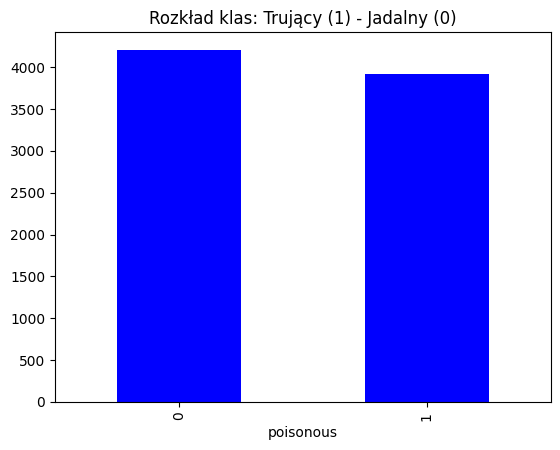

In [ ]:
Y['poisonous'].value_counts().sort_index().plot(kind='bar', color='blue')
plt.title("Rozkład klas: Trujący (1) - Jadalny (0)")
plt.show()

Rozkład klasy trujący-jadalny jest równomierny.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y['poisonous'], test_size=0.2, random_state=42, stratify=Y['poisonous'])

## Modele

#### Wybór moodeli
1. Potrzebujemy względnie taniego pamięciowo, obliczeniowo i czasowo modelu, który jednak zapewni bezpieczne grzybobranie. Ponadto chcielibyśmy aby każda decyzja była uzasadniona i umożliwiała ewenetualną własną analizę. Dlatego wybór modeli to
- pojedyncze drzewo decyzyjne - bardzo lekki i przede wszystkim bardzo szybki jeśli chodzi o predykcję, działa na logice **JEŚLI ... TO ...**, więc uzasadnienie będzie bardzo logiczne. Ponadto nasze dane są kategoryczne co dodatkowo przychyla nas na drzewo.
- Gradient Boosting - podobnie jak w zadaniu 1, spodziewamy się najlepszego "zespołu modeli", może będzie najlepszym modelem i w tym zadaniu
- Bagging - celem jest las losowy, chcemy zobaczyć wyniki, jednak przez konieczność tworzenia wielu rozdzielnych drzew, prawdopodobnie nie będzie brany pod uwagę przy wyborze modelu

## 2.1 Pojedyncze drzewo decyzyjne

=== Wyniki walidacji krzyżowej ===
Średnia dokładność: 0.9763
Odchylenie standardowe: 0.0019

=== Trening modelu ===

=== Raport klasyfikacji ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       842
           1       0.97      0.99      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



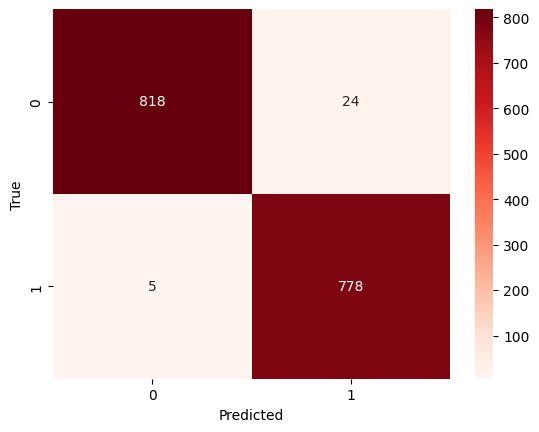

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)

cv_tree = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_tree_scores = cross_val_score(tree, X_train, y_train, cv=cv_tree)

print("=== Wyniki walidacji krzyżowej ===")
print(f"Średnia dokładność: {cv_tree_scores.mean():.4f}")
print(f"Odchylenie standardowe: {cv_tree_scores.std():.4f}")

print("\n=== Trening modelu ===")
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Raport klasyfikacji ===")
print(classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Najlepsze parametry: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}
Czas operacji: 0.00825 s


=== Raport klasyfikacji (po wytrenowaniu) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



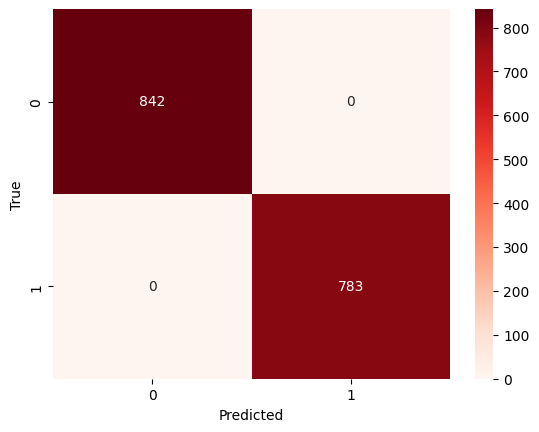

In [ ]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(f"Najlepsze parametry: {best_params}")
start = time.perf_counter()
best_tree = grid_search.best_estimator_
y_pred_tree_tuned = best_tree.predict(X_test)
time_taken = time.perf_counter() - start
print(f"Czas operacji: {time_taken:.5f} s\n")

print("\n=== Raport klasyfikacji (po wytrenowaniu) ===")
print(classification_report(y_test, y_pred_tree_tuned))
cm = confusion_matrix(y_test, y_pred_tree_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

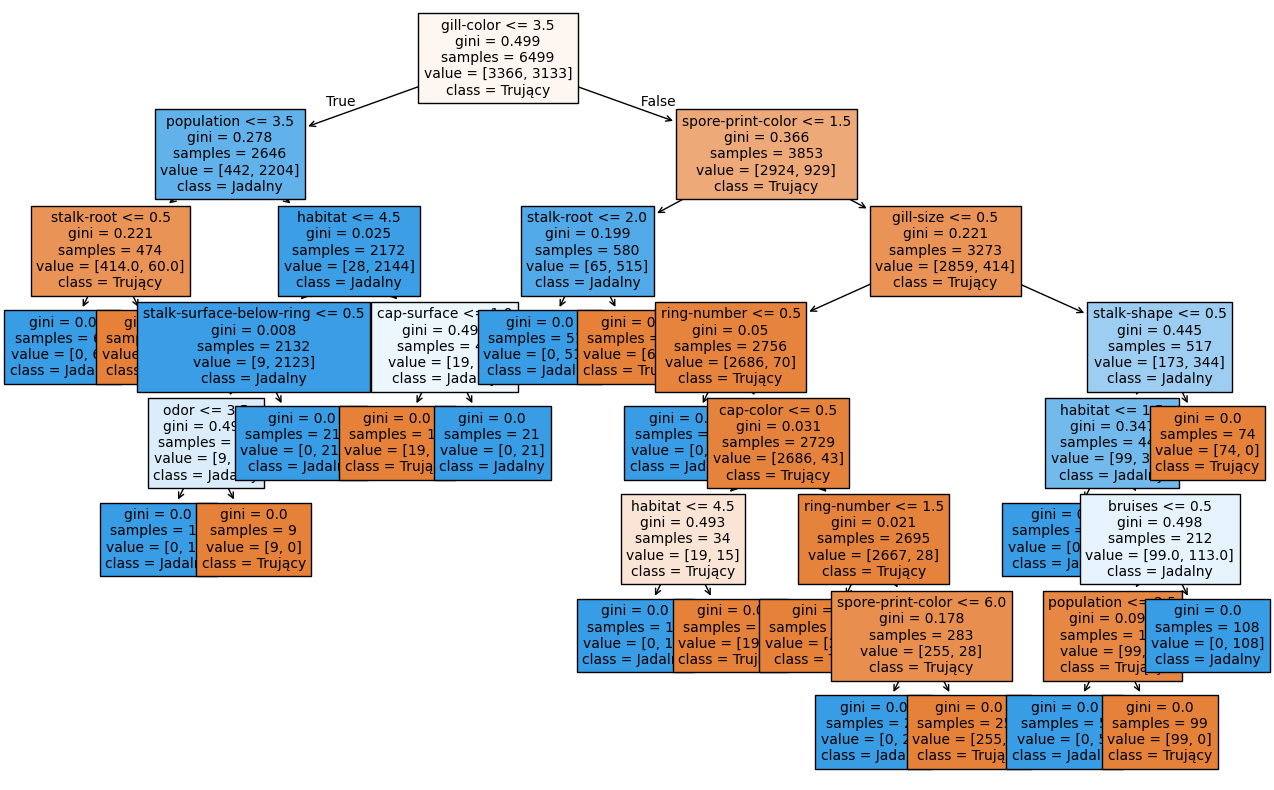

In [ ]:
plt.figure(figsize=(16, 10))
plot_tree(best_tree, feature_names=X_train.columns, class_names=['Trujący', 'Jadalny'], filled=True, fontsize=10)
plt.show()

## 2.2 Gradient Boosting

In [ ]:
n_estimators_list = [10, 50, 100]
learning_rates = [0.1, 0.01]
max_depths = [2, 3, 4]

results = []

for n_est, lr, depth in itertools.product(n_estimators_list, learning_rates, max_depths):
    gb_clf = GradientBoostingClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=depth,
        random_state=42
    )

    start_time = time.perf_counter()
    gb_clf.fit(X_train, y_train)
    y_pred = gb_clf.predict(X_test)
    elapsed_time = time.perf_counter() - start_time

    recall = recall_score(y_test, y_pred, pos_label=1)

    results.append({
        'n_estimators': n_est,
        'learning_rate': lr,
        'max_depth': depth,
        'Recall (Bezpieczeństwo)': round(recall, 4),
        'Czas operacji [s]': round(elapsed_time, 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=['Recall (Bezpieczeństwo)', 'Czas operacji [s]'],
    ascending=[False, True]
).reset_index(drop=True)

print(results_df.to_string())

    n_estimators  learning_rate  max_depth  Recall (Bezpieczeństwo)  Czas operacji [s]
0             50           0.10          4                   1.0000             0.6969
1            100           0.10          4                   1.0000             0.8822
2            100           0.10          3                   1.0000             1.0823
3             50           0.10          3                   0.9974             0.5350
4            100           0.10          2                   0.9962             0.9034
5             50           0.01          4                   0.9936             0.6867
6             10           0.01          4                   0.9923             0.1441
7             10           0.10          4                   0.9847             0.1553
8             50           0.10          2                   0.9847             0.4223
9            100           0.01          4                   0.9847             1.3174
10            10           0.10          3 

Czas operacji (Trening + Predykcja): 0.54361 s

=== Raport klasyfikacji (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



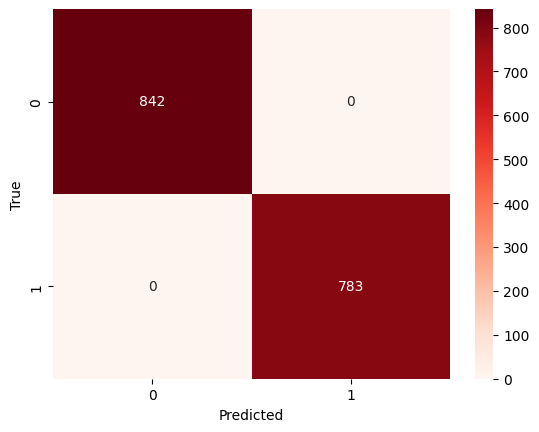

In [ ]:
gb_clf = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

start_time_gb = time.perf_counter()
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
elapsed_time_gb = time.perf_counter() - start_time_gb

print(f"Czas operacji (Trening + Predykcja): {elapsed_time_gb:.5f} s\n")

print("=== Raport klasyfikacji (Gradient Boosting) ===")
print(classification_report(y_test, y_pred_gb))

cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## 2.3 Bagging

In [ ]:
n_estimators_list = [10, 50, 100]
max_samples_list = [0.5, 0.7, 1.0]
max_depths = [5, 6, 7]

results_bagging = []

for n_est, max_samp, depth in itertools.product(n_estimators_list, max_samples_list, max_depths):

    base_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    bagging_clf = BaggingClassifier(
        estimator=base_tree,
        n_estimators=n_est,
        max_samples=max_samp,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.perf_counter()

    bagging_clf.fit(X_train, y_train)
    y_pred = bagging_clf.predict(X_test)

    elapsed_time = time.perf_counter() - start_time

    recall = recall_score(y_test, y_pred, pos_label=1)

    results_bagging.append({
        'n_estimators': n_est,
        'max_samples': max_samp,
        'max_depth': depth,
        'Recall (Bezpieczeństwo)': round(recall, 4),
        'Czas operacji [s]': round(elapsed_time, 4)
    })

results_bagging_df = pd.DataFrame(results_bagging)

results_bagging_df = results_bagging_df.sort_values(
    by=['Recall (Bezpieczeństwo)', 'Czas operacji [s]'],
    ascending=[False, True]
).reset_index(drop=True)

print(results_bagging_df.to_string())

    n_estimators  max_samples  max_depth  Recall (Bezpieczeństwo)  Czas operacji [s]
0             10          0.7          7                   1.0000             0.1463
1             10          0.5          7                   1.0000             0.1508
2             10          1.0          7                   1.0000             0.4016
3             50          0.5          7                   1.0000             0.4777
4             50          0.7          7                   1.0000             0.6856
5            100          0.7          7                   1.0000             0.7340
6            100          1.0          7                   1.0000             0.7911
7            100          0.5          7                   1.0000             0.8310
8             50          1.0          7                   1.0000             1.0810
9             10          0.5          6                   0.9949             0.1450
10            10          1.0          6                   0.9949

Czas operacji (Trening + Predykcja): 0.14052

=== Raport klasyfikacji (Bagging) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



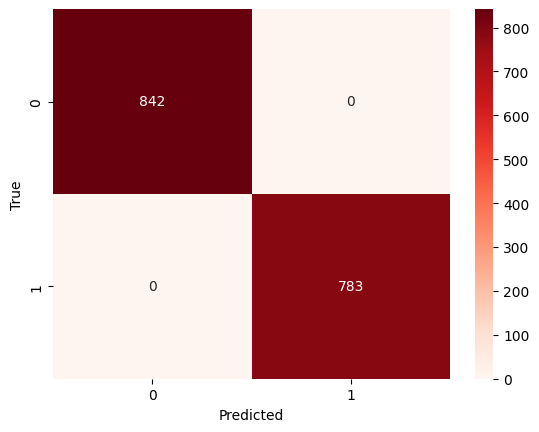

In [ ]:
bg_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=7, random_state=42),
    n_estimators=10,
    max_samples=0.7,
    random_state=42,
    n_jobs=-1
)

start_time_bg = time.perf_counter()
bg_tree.fit(X_train, y_train)
y_pred_bg = bg_tree.predict(X_test)
elapsed_time_bg = time.perf_counter() - start_time_bg

print(f"Czas operacji (Trening + Predykcja): {elapsed_time_bg:.5f}\n")

print("=== Raport klasyfikacji (Bagging) ===")
print(classification_report(y_test, y_pred_bg))

cm = confusion_matrix(y_test, y_pred_bg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Podsumowanie

|Model / cecha|Recall|Czas|Interpretowalny|Zasoby|Decyzja|
|---|---|---|---|---|---|
|Pojedyncze drzewo decyzyjne|100%|0.001s|klarowny przebieg rozumowania|bardzo małe (tylko jeden algorytm)|TAK|
|Gradient Boosting|100%|0.67s|tylko wynik|spore (sekwencyjne budowanie 50 drzew)|Nie|
|Bagging|100%|0.15s|tylko wynik|średnie (jednoczesne budowanie 10 drzew)|Nie|

Po analizie trzech modeli opartych na drzewach, czas na anlizę i wnioski:
1. Cel i środki

Celem było stworzenie modelu, któremu uda się zachować balans między bezpieczną predykcją jadalności grzybów, a zużyciem zasobów (pamięci i baterii telefonu) w krytycznych warunkach. Ponieważ kluczem jest przetrwanie, mogliśmy się skupić wyłącznie na uniknięciu przeoczenia trującego okazu, pomijając fałszywe alarmy. Ważną częścią procesu rekrutacji modeli jest również możliwość łatwego odczytania, dlaczego podjęły taką a nie inną decyzję


2. Rekomendowany model - pojedyncze drzewo decyzyjne

Zdecydowanie najlepszy model zarówno pod względem czasowym jak i złożoności. Potrzebuje raptem ułamek milisekund, a jest w stanie w 100% odróżnić grzyby jadalne i niebezpieczne. Ponadto kolejną zaletą jest możliwość uzasadnienia swojej decyzji (co widać na wykresie drzewa). Swoje atuty jest w stanie zachować nawet pomimo konieczność optymalizacji do `max_depth=7`.

3. Pozostałe modele

- Gradient Boosting - z jednej strony jest to model najinteligentniejszy, ponieważ potrzebował zaledwie drzew o głębokości 4 aby osiągnąć 100% skuteczności. Kluczowe stały się jednak warunki polowe, gdyż jest to równocześnie model najwolniejszy oraz najmocniej obciążający pamięć i baterię telefonu (potrzebował zbudować 50 drzew jedno po drugim) Ponadto model nie dawałby szans na jawne wyjaśnienie swoich decyzji.
- Bagging - zaletą jest szybkość (raptem 0.15s), jednak wymagał głębokości drzew 7, tak jak pojedyncze drzewo. Więc tym samym nie dawałby żadnych wymiernych korzyści poza niepotrzebnym skomplikowaniem. Tutaj również minusem jest brak jawnej dedukcji